# Redes neurais em problemas de classificação

## Construindo uma rede neural MLP classificadora com o módulo `Lightning`

###### Notebook por Ana Carolina Sayumi I. Alves

## Aviso!!

Este notebook assume que o leitor conhece os conceitos utilizados e aplicados em redes neurais do tipo MLP classificadora, bem como assume conhecimento prévio acerca do módulo Lightning e sua aplicação e da arquitetura de MLPs. 

Caso não esteja familiarizado com problemas de classificação, recomenda-se a leitura do material introdutório disponível no GitHub sob nome de "Trilha da Academica - introdução.ipynb".

Caso não esteja familiarizado com o módulo, recomenda-se a leitura da documentação [1] e caso não esteja familiarizado com MLPs, recomenda-se o vídeo da referência [2]. 

Dito isso, boa leitura!

## Introdução

Problemas de classificação são de grande relevância para a ciência, desde a determinação de autorias à atribuição de características físico-químicas de materiais. Sendo assim, neste notebook iremos explorar a construção de uma rede neural do tipo MLP para um problema de classificação didático utilizando o módulo `Lightning`.

Vale dizer que, como a implementação de uma MLP utilizando o módulo é a mesma para o caso binário e multiclasse, pela maneira como ele é contruído internamente, iremos fazer apenas o exemplo mais generalizado, ou seja, o multiclasse.

## Imports necessários

Inicialmente, iremos importar todos os módulos e bibliotecas necessários para a implementação da rede.

In [37]:
import lightning as L
from torch.utils.data import DataLoader, TensorDataset

import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, MaxAbsScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torchmetrics import Accuracy, F1Score, ConfusionMatrix

import matplotlib.pyplot as plt


## O dataset

O dataset escolhido foi o dataset didático "Iris", que computa dados acerca da sépala e pétala de 3 diferentes espécies de flores. Nosso target serão as espécies.

In [38]:
sns.load_dataset("iris")

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


## Lightning `DataModule`

No `DataModule` é onde fazemos todo o tratamento de dados. Para um problema de classificação a principal diferença é o _encoding_ do target (que nesse caso não é feito por One-Hot, uma vez que nossa função de perda espera o formato de um inteiro representativo de uma classe e internamente faz essa codificação).

Vale ressaltar que **não** aplica-se um normalizador em nosso target, seja ele binário ou não, pois a função de perda espera apenas valores inteiros representativos de categorias.

In [39]:
class DataModule(L.LightningDataModule):
    def __init__(
        self,
        tamanho_teste=0.1,
        tamanho_val=0.1,
        tamanho_lote=32,
        num_trabalhadores=0,
        semente_aleatoria=41,
    ):
        super().__init__()

        self.tamanho_lote = tamanho_lote
        self.num_trabalhadores = num_trabalhadores
        self.tamanho_teste = tamanho_teste
        self.tamanho_val = tamanho_val
        self.semente_aleatoria = semente_aleatoria

    def prepare_data(self):
        """Local onde se faz o download do dataset. No caso do `seaborn`, ele
        deve baixar o dataset quando se usa pela primeira vez e por isso
        incluímos este código aqui.

        Não altere o estado da sua classe neste método!

        Se você não precisa fazer download de um dataset, pode eliminar este
        método.

        """
        sns.load_dataset("iris")

    def setup(self, stage):
        """Ocorre após o `prepare_data`. Aqui devemos alterar o estado da classe
        para adicionar as informações referentes aos conjuntos de treino, teste
        e validação. O argumento `stage` deve existir e ele indica em qual
        estágio o processo de treino está (pode ser `fit` para
        treinamento/validação e `test` para teste).

        É nesta etapa onde aplicamos transformações aos dados caso necessário.

        """
        ATRIBUTOS = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
        TARGET = ["species"]

        df = sns.load_dataset("iris")

        #Passando o Label Ecoder no target (sem ordem), mas com categorias definidas para
        #não perder informação ao longo do caminho e ser possível computar a métrica de perda
        encoder = OrdinalEncoder(categories=[['setosa', 'versicolor', 'virginica']])
        df[['species']] = encoder.fit_transform(df[['species']])

        df = df.reindex(ATRIBUTOS + TARGET, axis=1)
        df = df.dropna()

        indices = df.index
        indices_treino_val, indices_teste = train_test_split(
            indices,
            test_size=self.tamanho_teste,
            random_state=self.semente_aleatoria,
        )

        df_treino_val = df.loc[indices_treino_val]
        df_teste = df.loc[indices_teste]

        indices = df_treino_val.index
        indices_treino, indices_val = train_test_split(
            indices,
            test_size=self.tamanho_val,
            random_state=self.semente_aleatoria,
        )

        df_treino = df.loc[indices_treino]
        df_val = df.loc[indices_val]

        X_treino = df_treino.reindex(ATRIBUTOS, axis=1).values
        y_treino = df_treino.reindex(TARGET, axis=1).values

        self.x_scaler = MaxAbsScaler()
        self.x_scaler.fit(X_treino)

        if stage == "fit":
            X_val = df_val.reindex(ATRIBUTOS, axis=1).values
            y_val = df_val.reindex(TARGET, axis=1).values

            X_treino = self.x_scaler.transform(X_treino)
            X_val = self.x_scaler.transform(X_val)

            self.X_treino = torch.tensor(X_treino, dtype=torch.float32)
            self.X_val = torch.tensor(X_val, dtype=torch.float32)
    
            self.y_treino = torch.tensor(y_treino, dtype=torch.long).squeeze(1)
            self.y_val   = torch.tensor(y_val,   dtype=torch.long).squeeze(1)

        if stage == "test":
            X_teste = df_teste.reindex(ATRIBUTOS, axis=1).values
            y_teste = df_teste.reindex(TARGET, axis=1).values

            X_teste = self.x_scaler.transform(X_teste)

            self.X_teste = torch.tensor(X_teste, dtype=torch.float32)
            self.y_teste = torch.tensor(y_teste, dtype=torch.long).squeeze(1)

    def train_dataloader(self):
        return DataLoader(
            TensorDataset(self.X_treino, self.y_treino),
            batch_size=self.tamanho_lote,
            num_workers=self.num_trabalhadores,
            shuffle=True,
        )

    def val_dataloader(self):
        return DataLoader(
            TensorDataset(self.X_val, self.y_val),
            batch_size=self.tamanho_lote * 2,
            num_workers=self.num_trabalhadores,
            shuffle=False,
        )

    def test_dataloader(self):
        return DataLoader(
            TensorDataset(self.X_teste, self.y_teste),
            batch_size=self.tamanho_lote * 2,
            num_workers=self.num_trabalhadores,
            shuffle=False,
        )

## Definição da arquitetura

Aqui definimos a arquitetura de nossa MLP classificadora com 3 camadas ocultas, otimizador Adam e função de perda Cross Entropy Loss.

Repare que nossa camada de saída não é uma Softmax, como o esperado. Isso acontece porque a função de perda Cross Entropy, da mesma forma que faz o encoding internamente, também passa a função softmax nos dados.

In [40]:
class MLP_multiclass(L.LightningModule):
    def __init__(
        self, num_dados_entrada, neuronios_c1, neuronios_c2, neuronios_c3, num_targets):
        super().__init__()

        self.camadas = nn.Sequential(
            nn.Linear(num_dados_entrada, neuronios_c1),
            nn.ReLU(),
            nn.Linear(neuronios_c1, neuronios_c2),
            nn.ReLU(),
            nn.Linear(neuronios_c2, neuronios_c3),
            nn.ReLU(),
            nn.Linear(neuronios_c3, num_targets),
        )

        self.fun_perda = nn.CrossEntropyLoss()

        self.perdas_treino = []
        self.perdas_val = []

        self.curva_aprendizado_treino = []
        self.curva_aprendizado_val = []

    def forward(self, x):
        x = self.camadas(x)
        return x

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=1e-3)
        return optimizer

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.fun_perda(y_pred, y)

        self.log("loss", loss, prog_bar=True)
        self.perdas_treino.append(loss)

        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.fun_perda(y_pred, y)

        self.log("val_loss", loss, prog_bar=True)
        self.perdas_val.append(loss)

        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.fun_perda(y_pred, y)

        self.log("test_loss", loss)

        return loss

    def on_train_epoch_end(self):
        # Atualiza curva de aprendizado
        perda_media = torch.stack(self.perdas_treino).mean()
        self.curva_aprendizado_treino.append(float(perda_media))
        self.perdas_treino.clear()

    def on_validation_epoch_end(self):
        # Atualiza curva de aprendizado
        perda_media = torch.stack(self.perdas_val).mean()
        self.curva_aprendizado_val.append(float(perda_media))
        self.perdas_val.clear()

## Instanciamento da rede

Aqui definimos o número de época, bem como instanciamos o treinador e o DataModule.

In [41]:
NUM_EPOCAS = 200

treinador = L.Trainer(max_epochs=NUM_EPOCAS)

dm = DataModule()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


E finalmente passamos o número de classes na camada de saída, o número de atrbutos na de entrada, e instanciamos  e treinamos o modelo com $n$ neurônios por camada.

In [42]:
num_dados_de_entrada = 4
num_targets = 3
neuronios_c1 = 4
neuronios_c2 = 3
neuronios_c3 = 2

MLP_class_multi = MLP_multiclass(
    num_dados_de_entrada, neuronios_c1, neuronios_c2, neuronios_c3, num_targets)

treinador.fit(MLP_class_multi, dm)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name      | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | camadas   | Sequential       | 52     | train | 0    
1 | fun_perda | CrossEntropyLoss | 0      | train | 0    
---------------------------------------------------------------
52        Trainable params
0         Non-trainable params
52        Total params
0.000     Total estimated model params size (MB)
9         Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

C:\Users\ana25003\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\ana25003\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
C:\Users\ana25003\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
C:\Users\ana25003\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of tra

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


### Curva de aprendizado

Uma vez com feito o treino podemos olhar para a curva de aprendizado do modelo e checar se não está havendo um over ou underfitting.

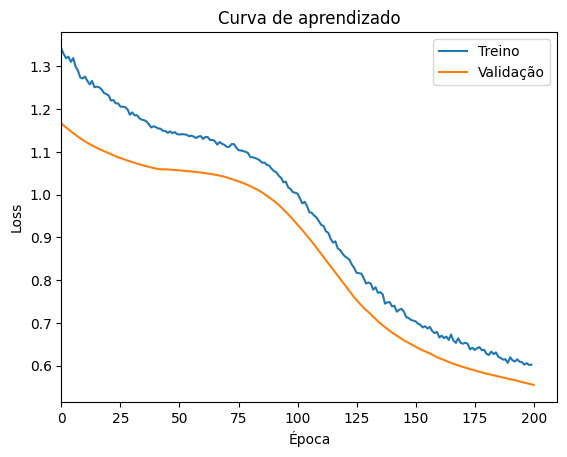

In [43]:
ca_treino = MLP_class_multi.curva_aprendizado_treino
ca_val = MLP_class_multi.curva_aprendizado_val

sns.lineplot(ca_treino, label="Treino")
eixo = sns.lineplot(ca_val, label="Validação")

eixo.set_xlim(left=0)
eixo.set(title="Curva de aprendizado", xlabel="Época", ylabel="Loss");

Para o nosso caso, nossa rede não parece apresentar nem o caso de overfitting, nem o caso de underfitting. Sendo assim, podemos seguir para o teste para ter certeza.

Mas antes, não vamos nos esquecer de salvar os pesos e viése utilizados, para garantir reprodutibilidade.

In [44]:
nome_arquivo = "dados_MLP_Multiclass.pth"
torch.save(MLP_class_multi.state_dict(), nome_arquivo)

Assim podemos instanciar a rede com o que foi salvo e finalmente testar seu desempenho.

In [45]:
MLP_class_multi = MLP_multiclass(
    num_dados_de_entrada, neuronios_c1, neuronios_c2, neuronios_c3, num_targets
)

state_dict = torch.load("dados_MLP_Multiclass.pth", weights_only=True)
MLP_class_multi.load_state_dict(state_dict)

treinador.fit(MLP_class_multi, dm)

C:\Users\ana25003\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:881: Checkpoint directory c:\Users\ana25003\OneDrive - ILUM ESCOLA DE CIÊNCIA\Documentos\ILUM\ILUM - 3ºsemestre\Redes Neurais e Algoritmos Genéticos\NN - Redes Neurais\lightning_logs\version_378\checkpoints exists and is not empty.

  | Name      | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | camadas   | Sequential       | 52     | train | 0    
1 | fun_perda | CrossEntropyLoss | 0      | train | 0    
---------------------------------------------------------------
52        Trainable params
0         Non-trainable params
52        Total params
0.000     Total estimated model params size (MB)
9         Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

C:\Users\ana25003\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\ana25003\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
C:\Users\ana25003\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
C:\Users\ana25003\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of tra

In [46]:
MLP_class_multi.eval()
dm.setup("test")

Acima deixamos o modelo em modo de avaliação e processamos os dados de teste.

A seguir iremos realizar o teste e computar as métricas de acurácia e F1-Macro, bem como plotar a matriz de confusão.

## Resultado

In [47]:
with torch.no_grad():
    X_true = dm.X_teste
    y_true = dm.y_teste

    y_pred = MLP_class_multi(X_true)

    acuracia = Accuracy(task="multiclass", num_classes=3)
    f1 = F1Score(task="multiclass", num_classes=3, average="macro")

    print(f"A acurácia foi de: {acuracia(y_pred, y_true)}")
    print(f"O F1 Macro foi de: {f1(y_pred, y_true)}")

A acurácia foi de: 0.46666666865348816
O F1 Macro foi de: 0.5


Podemos observar que o desempenho do modelo não foi muito bom, com acurácia e F1 baixos. Idealmente, precisaríamos de um baseline comparativo, mas para fins didáticos de aplicação, acima de 0.7 seria aceitável.

Abaixo iremos fazer a matriz de confusão, para compreender melhor o que aconteceu na distribuição de classes do nosso problema.

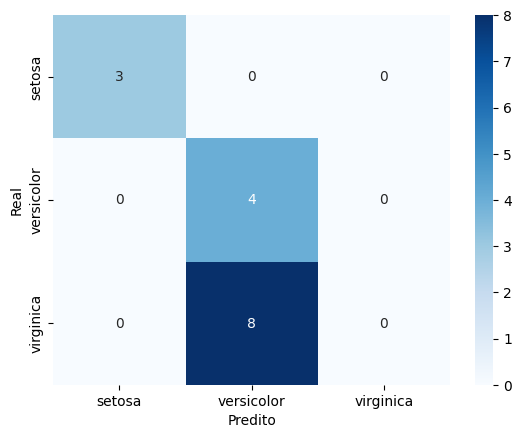

In [48]:
with torch.no_grad():
    X_true = dm.X_teste
    y_true = dm.y_teste
    y_pred = MLP_class_multi(X_true)

    confmat = ConfusionMatrix(task="multiclass", num_classes=3)
    matriz = confmat(y_pred, y_true).numpy()

fig, ax = plt.subplots()
sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["setosa", "versicolor", "virginica"],
    yticklabels=["setosa", "versicolor", "virginica"],
    ax=ax
)
ax.set_xlabel("Predito")
ax.set_ylabel("Real")
plt.show()

Pela matriz, podemos notar que dificilmente tivemos um overfitting, entretanto o modelo parece ter dificuldade em classificar a espécie virginica. Provavelmente com uma otimização de hiperparâmetros obteríamos um melhor desempenho. Olhando para a curva de aprendizado, talvez mais épocas também favorecessem o desempenho, mas deixo para futuras explorações.

## Conclusão

A implementação de redes neurais do tipo MLP classificadoras, em relação a regressoras, é relativamente simples, entretando é desejável que se tenha uma boa fundamentação teórica para que os resultados façam sentido e para que o processo seja mais fluido e tranquilo. Para esse notebook usamos um dataset didático e uma arquitetura interna correspondente à dificuldade do problema, mas vale dizer que para conjuntos de dados maiores e mais complexos, mais sofisticação precisamos adicionar à construção da MLP - como otimização, por exemplo - e mais espera-se que esse conhecimento básico aqui apresentado esteja consolidado.

## Referências

[1]`Lightning` [https://lightning.ai/docs/pytorch/stable/](https://lightning.ai/docs/pytorch/stable/)

[2] Andrej Karpathy. The spelled-out intro to neural networks and backpropagation: building micrograd (2022). [https://www.youtube.com/watch?v=VMj-3S1tku0](https://www.youtube.com/watch?v=VMj-3S1tku0)